# Tutorial Round — Market Data Analysis
Exploratory analysis of EMERALDS and TOMATOES price/trade data.
Goal: understand price dynamics to inform strategy design.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [3]:
pwd

'/Users/pranavkapur2/Code/prosperity-trading/notebook_analysis'

## 1. Load Data

In [2]:
# Load both days of price data
prices_d2 = pd.read_csv('../backtester/prosperity3bt/resources/round0/prices_round_0_day_-2.csv', sep=';')
prices_d1 = pd.read_csv('../backtester/prosperity3bt/resources/round0/prices_round_0_day_-1.csv', sep=';')
prices = pd.concat([prices_d2, prices_d1], ignore_index=True)

# Load both days of trade data
trades_d2 = pd.read_csv('../backtester/prosperity3bt/resources/round0/trades_round_0_day_-2.csv', sep=';')
trades_d1 = pd.read_csv('../backtester/prosperity3bt/resources/round0/trades_round_0_day_-1.csv', sep=';')
trades = pd.concat([trades_d2, trades_d1], ignore_index=True)

print('Prices shape:', prices.shape)
print('Trades shape:', trades.shape)
prices.head()

Prices shape: (40000, 17)
Trades shape: (1219, 7)


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,EMERALDS,9992,11,9990,25,NaN,NaN,10008,11,10010,25,NaN,NaN,10000.0,0.0
1,-2,0,TOMATOES,4993,7,4992,17,NaN,NaN,5007,7,5008,17,NaN,NaN,5000.0,0.0
2,-2,100,TOMATOES,4998,5,4993,7,4992.0,16.0,5007,7,5008,16,NaN,NaN,5002.5,0.0
3,-2,100,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0
4,-2,200,TOMATOES,4994,6,4993,20,NaN,NaN,5008,6,5009,20,NaN,NaN,5001.0,0.0


In [3]:
# Split by product
em = prices[prices['product'] == 'EMERALDS'].copy().reset_index(drop=True)
tom = prices[prices['product'] == 'TOMATOES'].copy().reset_index(drop=True)

em_trades = trades[trades['symbol'] == 'EMERALDS'].copy().reset_index(drop=True)
tom_trades = trades[trades['symbol'] == 'TOMATOES'].copy().reset_index(drop=True)

print(f'EMERALDS price rows: {len(em)}, trade rows: {len(em_trades)}')
print(f'TOMATOES price rows: {len(tom)}, trade rows: {len(tom_trades)}')

EMERALDS price rows: 20000, trade rows: 399
TOMATOES price rows: 20000, trade rows: 820


## 2. Basic Statistics

In [4]:
for name, df in [('EMERALDS', em), ('TOMATOES', tom)]:
    print(f'--- {name} ---')
    print(df['mid_price'].describe().round(2))
    print(f'Spread (ask1 - bid1) mean: {(df["ask_price_1"] - df["bid_price_1"]).mean():.2f}')
    print(f'Spread (ask1 - bid1) std:  {(df["ask_price_1"] - df["bid_price_1"]).std():.2f}')
    print()

--- EMERALDS ---
count    20000.00
mean     10000.00
std          0.72
min       9996.00
25%      10000.00
50%      10000.00
75%      10000.00
max      10004.00
Name: mid_price, dtype: float64
Spread (ask1 - bid1) mean: 15.74
Spread (ask1 - bid1) std:  1.42

--- TOMATOES ---
count    20000.00
mean      4992.76
std         19.75
min       4946.50
25%       4980.00
50%       4995.50
75%       5006.50
max       5036.00
Name: mid_price, dtype: float64
Spread (ask1 - bid1) mean: 13.02
Spread (ask1 - bid1) std:  1.75



## 3. Mid-Price Over Time
The most important chart — does the price mean-revert (EMERALDS) or drift (TOMATOES)?

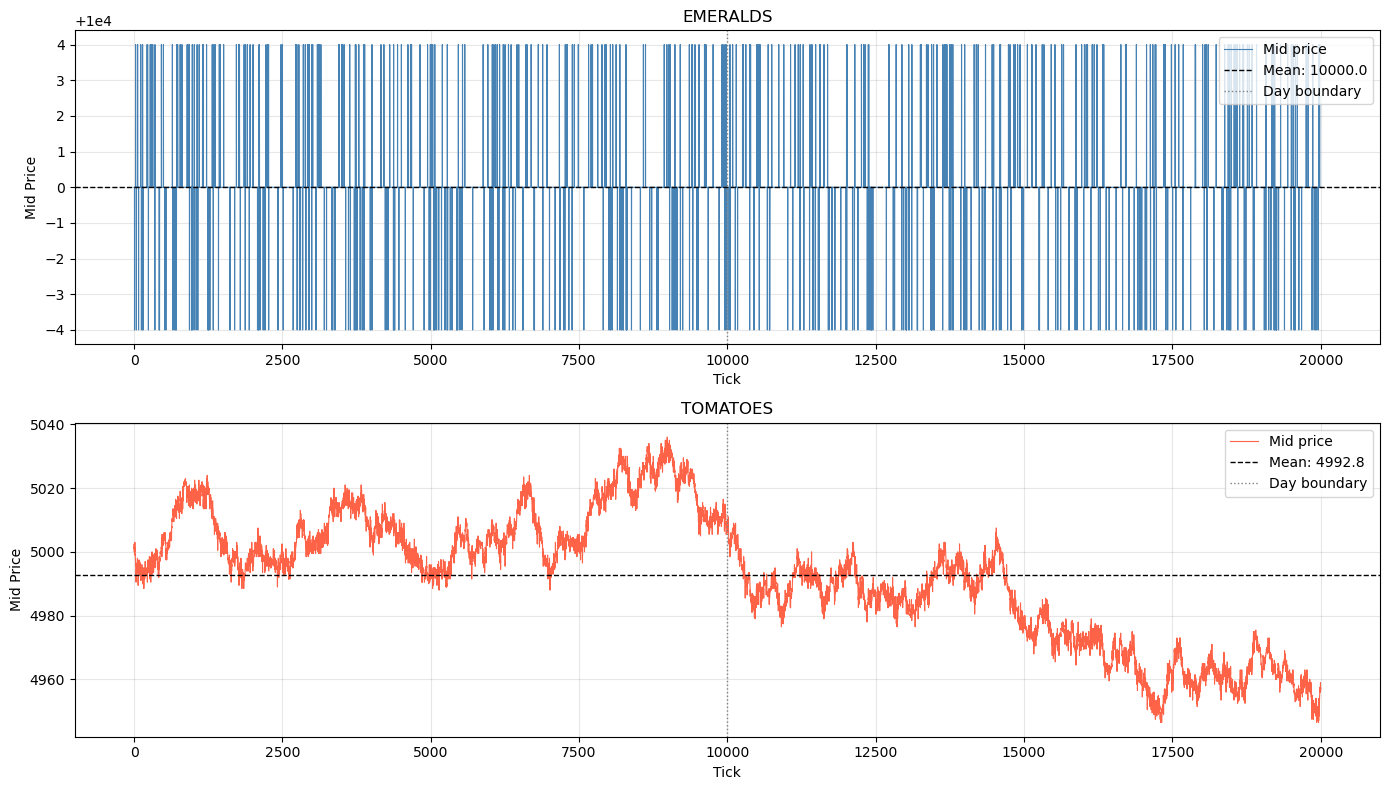

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for ax, df, name, color in zip(axes, [em, tom], ['EMERALDS', 'TOMATOES'], ['steelblue', 'tomato']):
    ax.plot(df.index, df['mid_price'], color=color, linewidth=0.8, label='Mid price')
    ax.axhline(df['mid_price'].mean(), color='black', linestyle='--', linewidth=1, label=f'Mean: {df["mid_price"].mean():.1f}')
    # Mark day boundary
    day_boundary = df[df['day'] == -1].index[0] if -1 in df['day'].values else None
    if day_boundary:
        ax.axvline(day_boundary, color='gray', linestyle=':', linewidth=1, label='Day boundary')
    ax.set_title(name)
    ax.set_xlabel('Tick')
    ax.set_ylabel('Mid Price')
    ax.legend()

plt.tight_layout()
plt.show()

## 4. Spread Analysis
How wide is the bid-ask spread? This determines how much edge we need to market-make profitably.

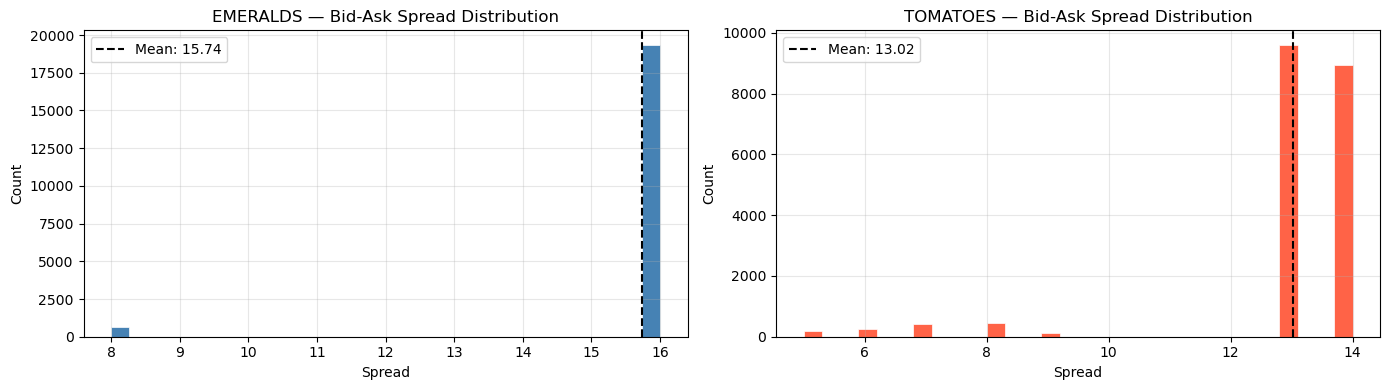

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, df, name, color in zip(axes, [em, tom], ['EMERALDS', 'TOMATOES'], ['steelblue', 'tomato']):
    spread = df['ask_price_1'] - df['bid_price_1']
    ax.hist(spread, bins=30, color=color, edgecolor='white', linewidth=0.5)
    ax.axvline(spread.mean(), color='black', linestyle='--', label=f'Mean: {spread.mean():.2f}')
    ax.set_title(f'{name} — Bid-Ask Spread Distribution')
    ax.set_xlabel('Spread')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.show()

## 5. Order Book Depth
How much volume sits at each level? Larger depth = more liquidity to trade against.

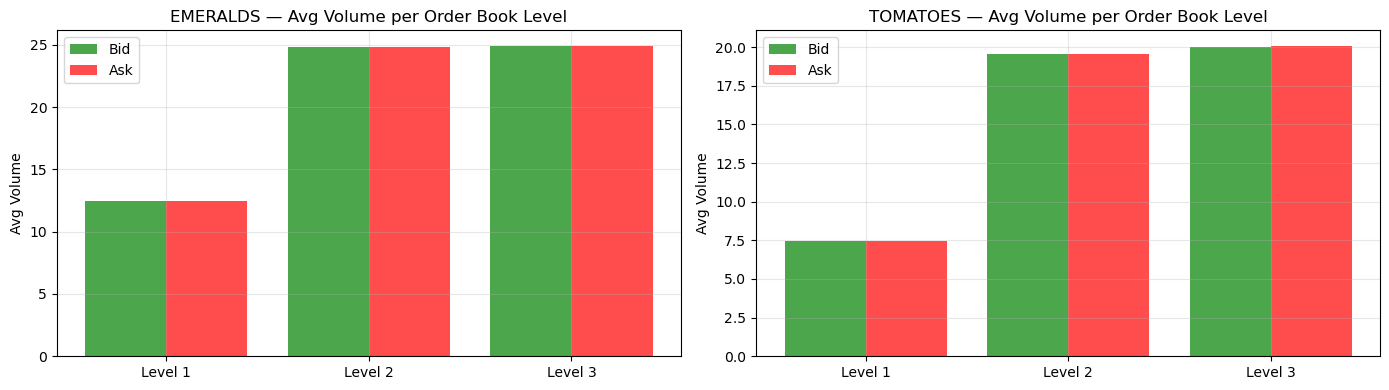

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, df, name, color in zip(axes, [em, tom], ['EMERALDS', 'TOMATOES'], ['steelblue', 'tomato']):
    bid_depth = df[['bid_volume_1', 'bid_volume_2', 'bid_volume_3']].mean()
    ask_depth = df[['ask_volume_1', 'ask_volume_2', 'ask_volume_3']].mean()
    levels = ['Level 1', 'Level 2', 'Level 3']
    x = np.arange(len(levels))
    ax.bar(x - 0.2, bid_depth, 0.4, label='Bid', color='green', alpha=0.7)
    ax.bar(x + 0.2, ask_depth, 0.4, label='Ask', color='red', alpha=0.7)
    ax.set_title(f'{name} — Avg Volume per Order Book Level')
    ax.set_xticks(x)
    ax.set_xticklabels(levels)
    ax.set_ylabel('Avg Volume')
    ax.legend()

plt.tight_layout()
plt.show()

## 6. TOMATOES — Drift Analysis
Key question: how fast does the price drift, and does it reverse?

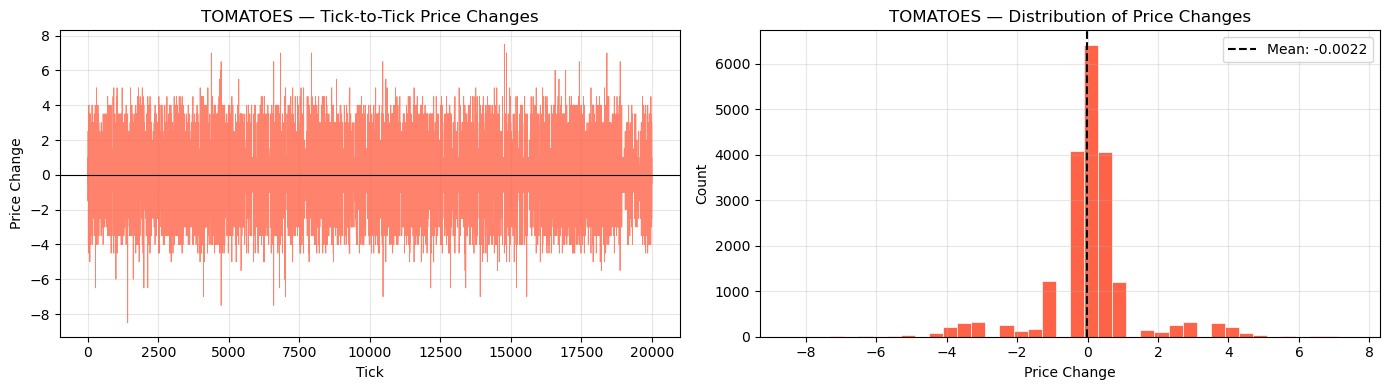

Mean return per tick: -0.0022
Std of returns:       1.3410
% positive ticks:     33.8%
% negative ticks:     34.1%


In [8]:
# Tick-to-tick returns
tom['returns'] = tom['mid_price'].diff()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Returns over time
axes[0].plot(tom.index, tom['returns'], color='tomato', linewidth=0.6, alpha=0.8)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('TOMATOES — Tick-to-Tick Price Changes')
axes[0].set_xlabel('Tick')
axes[0].set_ylabel('Price Change')

# Distribution of returns
axes[1].hist(tom['returns'].dropna(), bins=40, color='tomato', edgecolor='white', linewidth=0.5)
axes[1].axvline(tom['returns'].mean(), color='black', linestyle='--',
                label=f'Mean: {tom["returns"].mean():.4f}')
axes[1].set_title('TOMATOES — Distribution of Price Changes')
axes[1].set_xlabel('Price Change')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Mean return per tick: {tom["returns"].mean():.4f}')
print(f'Std of returns:       {tom["returns"].std():.4f}')
print(f'% positive ticks:     {(tom["returns"] > 0).mean()*100:.1f}%')
print(f'% negative ticks:     {(tom["returns"] < 0).mean()*100:.1f}%')

## 7. TOMATOES — Moving Averages
Test different window sizes to see which tracks the drift best without lagging too much.

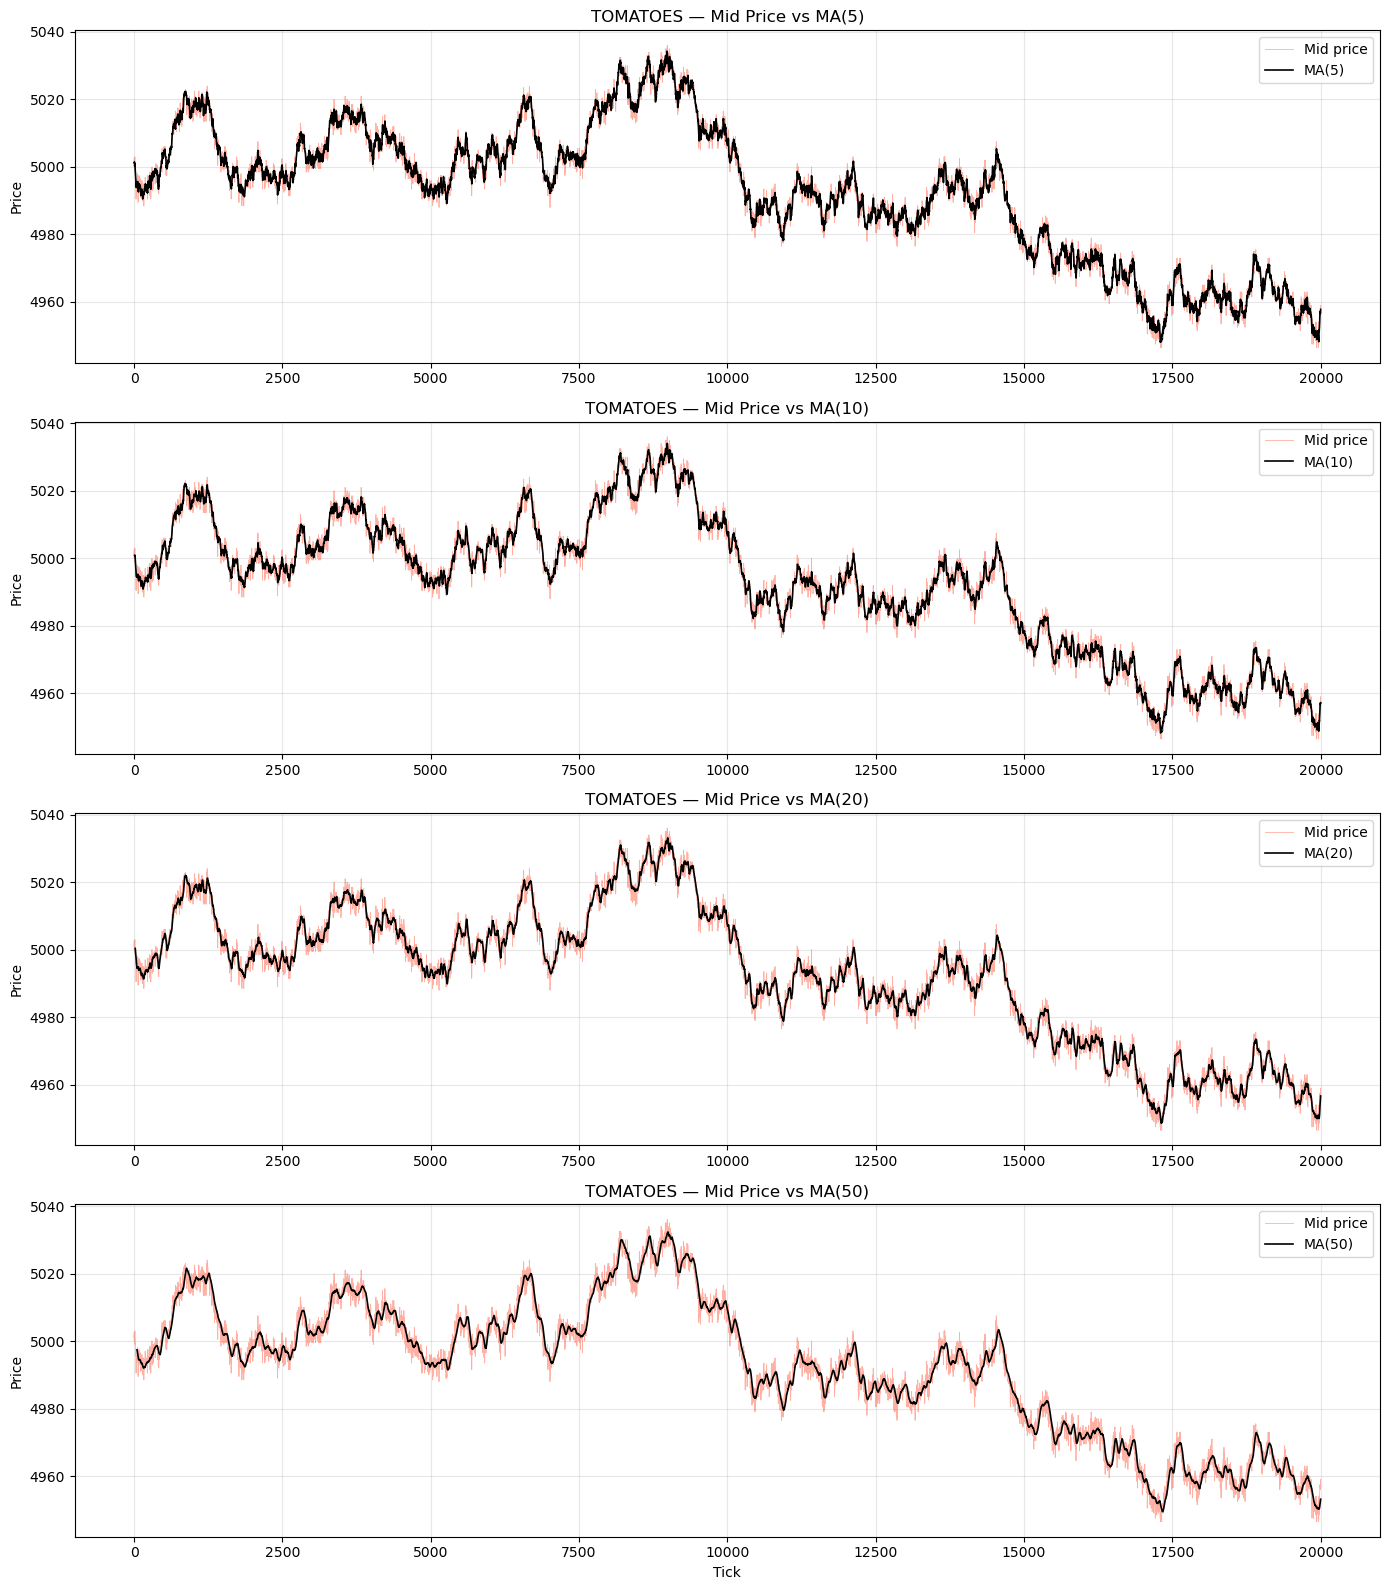

In [9]:
windows = [5, 10, 20, 50]

fig, axes = plt.subplots(len(windows), 1, figsize=(14, 4 * len(windows)))

for ax, w in zip(axes, windows):
    ma = tom['mid_price'].rolling(w).mean()
    ax.plot(tom.index, tom['mid_price'], color='tomato', linewidth=0.6, alpha=0.5, label='Mid price')
    ax.plot(tom.index, ma, color='black', linewidth=1.2, label=f'MA({w})')
    ax.set_title(f'TOMATOES — Mid Price vs MA({w})')
    ax.set_ylabel('Price')
    ax.legend()

axes[-1].set_xlabel('Tick')
plt.tight_layout()
plt.show()

## 8. TOMATOES — Mean Reversion Check
Does price revert to its moving average, or keep trending away from it?
If the deviation from MA tends to grow → trending. If it shrinks → mean-reverting.

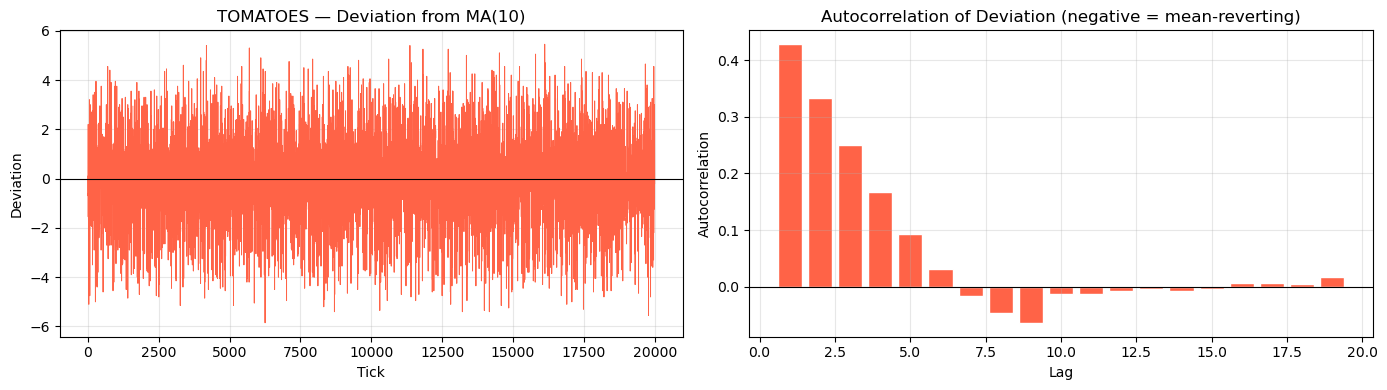

In [10]:
w = 10
tom['ma'] = tom['mid_price'].rolling(w).mean()
tom['deviation'] = tom['mid_price'] - tom['ma']

# Autocorrelation of deviation — negative autocorrelation = mean-reverting
autocorr_lags = range(1, 20)
autocorrs = [tom['deviation'].dropna().autocorr(lag=lag) for lag in autocorr_lags]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(tom.index, tom['deviation'], color='tomato', linewidth=0.7)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title(f'TOMATOES — Deviation from MA({w})')
axes[0].set_xlabel('Tick')
axes[0].set_ylabel('Deviation')

axes[1].bar(autocorr_lags, autocorrs, color='tomato', edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Autocorrelation of Deviation (negative = mean-reverting)')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Autocorrelation')

plt.tight_layout()
plt.show()

## 9. EMERALDS — Mean Reversion Confirmation
Verify that EMERALDS reliably reverts to 10,000 — and how quickly.

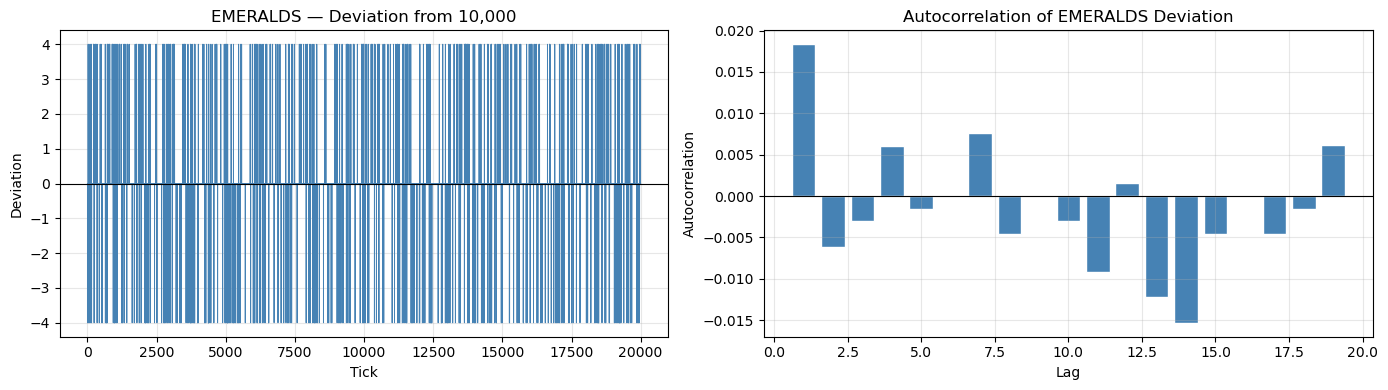

Max deviation from 10,000: 4.0
Std of deviation:          0.72


In [11]:
EMERALDS_FAIR = 10000
em['deviation'] = em['mid_price'] - EMERALDS_FAIR

autocorr_lags = range(1, 20)
autocorrs = [em['deviation'].autocorr(lag=lag) for lag in autocorr_lags]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(em.index, em['deviation'], color='steelblue', linewidth=0.7)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('EMERALDS — Deviation from 10,000')
axes[0].set_xlabel('Tick')
axes[0].set_ylabel('Deviation')

axes[1].bar(autocorr_lags, autocorrs, color='steelblue', edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Autocorrelation of EMERALDS Deviation')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Autocorrelation')

plt.tight_layout()
plt.show()

print(f'Max deviation from 10,000: {em["deviation"].abs().max():.1f}')
print(f'Std of deviation:          {em["deviation"].std():.2f}')

## 10. Trade Activity
When do trades happen, and at what prices relative to the mid?

EMERALDS:
  Total trades:      399
  Avg quantity:      5.5
  Avg trade vs mid:  -0.21
  Trades above mid:  190 (47.6%)
  Trades below mid:  202 (50.6%)

TOMATOES:
  Total trades:      820
  Avg quantity:      3.5
  Avg trade vs mid:  -15.94
  Trades above mid:  211 (25.7%)
  Trades below mid:  609 (74.3%)



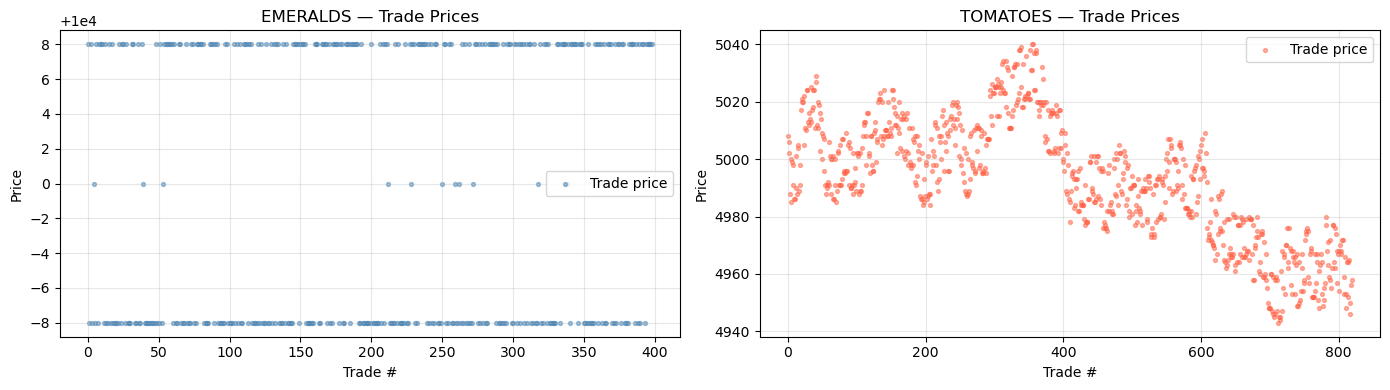

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, t_df, p_df, name, color in zip(
    axes,
    [em_trades, tom_trades],
    [em, tom],
    ['EMERALDS', 'TOMATOES'],
    ['steelblue', 'tomato']
):
    t_df = t_df.copy()
    mid_lookup = p_df.drop_duplicates('timestamp').set_index('timestamp')['mid_price']
    t_df['mid_price'] = t_df['timestamp'].map(mid_lookup)
    t_df['trade_vs_mid'] = t_df['price'] - t_df['mid_price']

    ax.scatter(range(len(t_df)), t_df['price'], s=8, alpha=0.5, color=color, label='Trade price')
    ax.set_title(f'{name} — Trade Prices')
    ax.set_xlabel('Trade #')
    ax.set_ylabel('Price')
    ax.legend()

    print(f'{name}:')
    print(f'  Total trades:      {len(t_df)}')
    print(f'  Avg quantity:      {t_df["quantity"].mean():.1f}')
    print(f'  Avg trade vs mid:  {t_df["trade_vs_mid"].mean():.2f}')
    print(f'  Trades above mid:  {(t_df["trade_vs_mid"] > 0).sum()} ({(t_df["trade_vs_mid"] > 0).mean()*100:.1f}%)')
    print(f'  Trades below mid:  {(t_df["trade_vs_mid"] < 0).sum()} ({(t_df["trade_vs_mid"] < 0).mean()*100:.1f}%)')
    print()

plt.tight_layout()
plt.show()

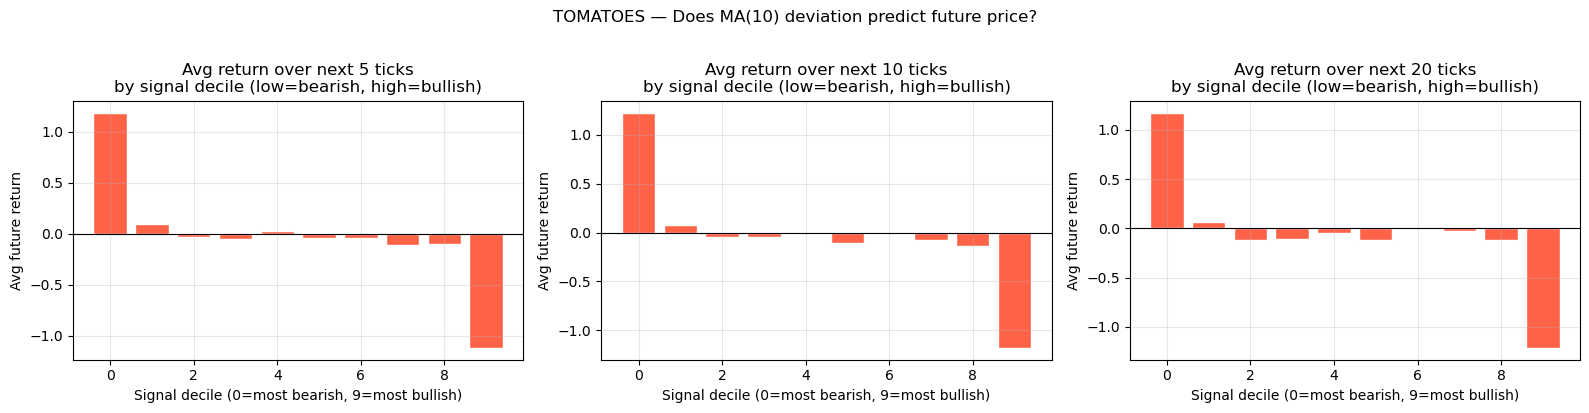

Signal vs 5-tick forward return correlation: -0.3672
Signal vs 10-tick forward return correlation: -0.3141
Signal vs 20-tick forward return correlation: -0.2453


In [15]:
w = 10
tom['ma'] = tom['mid_price'].rolling(w).mean()
tom['signal'] = tom['mid_price'] - tom['ma']
tom['future_return_5']  = tom['mid_price'].shift(-5)  - tom['mid_price']
tom['future_return_10'] = tom['mid_price'].shift(-10) - tom['mid_price']
tom['future_return_20'] = tom['mid_price'].shift(-20) - tom['mid_price']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, horizon in zip(axes, ['future_return_5', 'future_return_10', 'future_return_20'], [5, 10, 20]):
    data = tom[['signal', col]].dropna()
    data['signal_bin'] = pd.qcut(data['signal'], q=10, labels=False)
    mean_returns = data.groupby('signal_bin')[col].mean()
    ax.bar(mean_returns.index, mean_returns.values, color='tomato', edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'Avg return over next {horizon} ticks\nby signal decile (low=bearish, high=bullish)')
    ax.set_xlabel('Signal decile (0=most bearish, 9=most bullish)')
    ax.set_ylabel('Avg future return')

plt.suptitle('TOMATOES — Does MA(10) deviation predict future price?', y=1.02)
plt.tight_layout()
plt.show()

for col, h in [('future_return_5', 5), ('future_return_10', 10), ('future_return_20', 20)]:
    corr = tom[['signal', col]].dropna().corr().iloc[0, 1]
    print(f'Signal vs {h}-tick forward return correlation: {corr:.4f}')

MA window prediction quality (lower MAE/RMSE = better fair value estimate):
 window      mae     rmse     bias
      3 0.825199 1.200993 0.004426
      5 0.869197 1.228560 0.006602
     10 0.997634 1.354876 0.011946
     20 1.228697 1.603903 0.022544
     50 1.759002 2.219033 0.052676


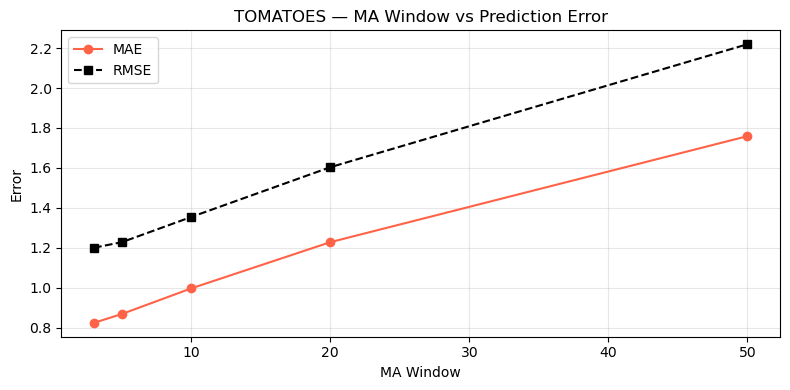

In [16]:
windows = [3, 5, 10, 20, 50]
results = []

for w in windows:
    ma = tom['mid_price'].rolling(w).mean()
    error = (ma - tom['mid_price'].shift(-1)).dropna()
    results.append({
        'window': w,
        'mae': error.abs().mean(),
        'rmse': np.sqrt((error**2).mean()),
        'bias': error.mean()
    })

results_df = pd.DataFrame(results)
print('MA window prediction quality (lower MAE/RMSE = better fair value estimate):')
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(results_df['window'], results_df['mae'], marker='o', color='tomato', label='MAE')
ax.plot(results_df['window'], results_df['rmse'], marker='s', color='black', linestyle='--', label='RMSE')
ax.set_title('TOMATOES — MA Window vs Prediction Error')
ax.set_xlabel('MA Window')
ax.set_ylabel('Error')
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
FAIR = 10000
edges = range(1, 9)
results = []

for edge in edges:
    our_bid = FAIR - edge
    our_ask = FAIR + edge
    bot_bid = em['bid_price_1']
    bot_ask = em['ask_price_1']

    ask_fills = (bot_bid >= our_ask).sum()
    bid_fills = (bot_ask <= our_bid).sum()

    results.append({
        'edge': edge,
        'our_bid': our_bid,
        'our_ask': our_ask,
        'ask_fills': int(ask_fills),
        'bid_fills': int(bid_fills),
        'spread_per_rt': edge * 2,
    })

res_df = pd.DataFrame(results)
print('EMERALDS — Quote placement analysis:')
print(res_df.to_string(index=False))
print()
print('Bot quotes are fixed at 9992 bid / 10008 ask.')
print('Passive fills only happen when bots send aggressive orders crossing our quotes.')

EMERALDS — Quote placement analysis:
 edge  our_bid  our_ask  ask_fills  bid_fills  spread_per_rt
    1     9999    10001          0          0              2
    2     9998    10002          0          0              4
    3     9997    10003          0          0              6
    4     9996    10004          0          0              8
    5     9995    10005          0          0             10
    6     9994    10006          0          0             12
    7     9993    10007          0          0             14
    8     9992    10008          0          0             16

Bot quotes are fixed at 9992 bid / 10008 ask.
Passive fills only happen when bots send aggressive orders crossing our quotes.


In [18]:
# When do bots quote tighter than usual on EMERALDS?
em['spread'] = em['ask_price_1'] - em['bid_price_1']
em['best_ask_vs_fair'] = em['ask_price_1'] - 10000
em['best_bid_vs_fair'] = 10000 - em['bid_price_1']

print('EMERALDS ask price distribution:')
print(em['ask_price_1'].value_counts().sort_index())
print()
print('EMERALDS bid price distribution:')
print(em['bid_price_1'].value_counts().sort_index())
print()

# When ask < 10008, it's a taking opportunity (buying below normal ask)
take_buy  = em[em['ask_price_1'] < 10008]
take_sell = em[em['bid_price_1'] > 9992]
print(f'Ticks where ask < 10008 (buy opportunity): {len(take_buy)} ({len(take_buy)/len(em)*100:.1f}%)')
print(f'Ticks where bid > 9992 (sell opportunity): {len(take_sell)} ({len(take_sell)/len(em)*100:.1f}%)')

EMERALDS ask price distribution:
ask_price_1
10000      333
10008    19667
Name: count, dtype: int64

EMERALDS bid price distribution:
bid_price_1
9992     19679
10000      321
Name: count, dtype: int64

Ticks where ask < 10008 (buy opportunity): 333 (1.7%)
Ticks where bid > 9992 (sell opportunity): 321 (1.6%)


In [19]:
# Check level 2 quotes — maybe there's depth at better prices
print('EMERALDS bid_price_2 distribution:')
print(em['bid_price_2'].value_counts().sort_index())
print()
print('EMERALDS ask_price_2 distribution:')
print(em['ask_price_2'].value_counts().sort_index())
print()

# Also check: when ask=10000, what is bid at same tick?
same_tick = em[em['ask_price_1'] == 10000]
print('When ask=10000, bid_price_1 is:')
print(same_tick['bid_price_1'].value_counts().sort_index())
print()

same_tick2 = em[em['bid_price_1'] == 10000]
print('When bid=10000, ask_price_1 is:')
print(same_tick2['ask_price_1'].value_counts().sort_index())

EMERALDS bid_price_2 distribution:
bid_price_2
9990    19679
9992      321
Name: count, dtype: int64

EMERALDS ask_price_2 distribution:
ask_price_2
10008      333
10010    19667
Name: count, dtype: int64

When ask=10000, bid_price_1 is:
bid_price_1
9992    333
Name: count, dtype: int64

When bid=10000, ask_price_1 is:
ask_price_1
10008    321
Name: count, dtype: int64


In [20]:
# What happens to price AFTER a special tick?
# Does the bot at 10000 represent a large order we can partially fill,
# then the price snaps back giving us edge?

# More importantly - check the ask_volume_1 on special ticks
print('Ask volume when ask=10000:')
print(em[em['ask_price_1'] == 10000]['ask_volume_1'].value_counts().sort_index())
print()
print('Bid volume when bid=10000:')
print(em[em['bid_price_1'] == 10000]['bid_volume_1'].value_counts().sort_index())
print()

# And what are the volumes on normal ticks for comparison
print('Ask volume when ask=10008 (normal):')
print(em[em['ask_price_1'] == 10008]['ask_volume_1'].value_counts().sort_index())
print()
print('Bid volume when bid=9992 (normal):')
print(em[em['bid_price_1'] == 9992]['bid_volume_1'].value_counts().sort_index())

Ask volume when ask=10000:
ask_volume_1
5     39
6     55
7     61
8     57
9     64
10    57
Name: count, dtype: int64

Bid volume when bid=10000:
bid_volume_1
5     55
6     50
7     58
8     55
9     48
10    55
Name: count, dtype: int64

Ask volume when ask=10008 (normal):
ask_volume_1
10    3179
11    3187
12    3218
13    3337
14    3392
15    3354
Name: count, dtype: int64

Bid volume when bid=9992 (normal):
bid_volume_1
10    3183
11    3198
12    3230
13    3331
14    3388
15    3349
Name: count, dtype: int64


In [21]:
# What prices did EMERALDS trades actually execute at?
print('EMERALDS trade price distribution:')
print(em_trades['price'].value_counts().sort_index())
print()
print('EMERALDS trade quantity distribution:')
print(em_trades['quantity'].value_counts().sort_index())

EMERALDS trade price distribution:
price
9992.0     199
10000.0     11
10008.0    189
Name: count, dtype: int64

EMERALDS trade quantity distribution:
quantity
3    60
4    63
5    74
6    85
7    59
8    58
Name: count, dtype: int64
